In [1]:
## plots saved to workspace folder

In [1]:
from dustysn.model import calc_model_flux
from astropy import units as u
import matplotlib.pyplot as plt
import numpy as np
from dustysn.model import full_model
from dustysn.model import import_data, fit_dust_model


100 100


/Users/sophiakressy/dustysn/dustysn/model.py:236: FutureWarning: Passing 'z' as keyword is deprecated since version 7.0 and will stop working in a future release. Pass it positionally to suppress this warning.
  distance = calc_distance(redshift)


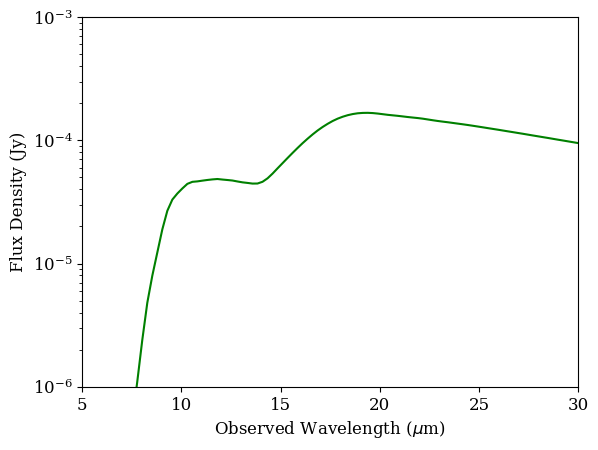

In [2]:
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.family': 'serif'})

# Basic parameters
dust_mass = 0.0008  # Solar masses
temperature = 158  # Kelvin
redshift = 0.001605
composition = 'silicate'  # 'carbon' or 'silicate'
grain_size = 0.1  # microns

# Wavelength grid (in microns)
obs_wave = np.linspace(5, 30, 100) * u.micron

# Calculate the model flux
model_flux = calc_model_flux(obs_wave, dust_mass, temperature, redshift,
                            grain_size=grain_size, composition=composition)

# Plot the model
print(len(obs_wave),len(model_flux))
plt.plot(obs_wave, model_flux, 'g')
plt.xlabel(r'Observed Wavelength ($\mu$m)')
plt.ylabel('Flux Density (Jy)')
plt.yscale('log')
plt.ylim(1e-6, 1e-3)
plt.xlim(5, 30)
plt.show()

# SN1983V

In [5]:
# Define the parameters of the model
# filename = '/Users/sophiakressy/Desktop/opt_flux2.txt' # File containing the data
filename = '/Users/sophiakressy/Desktop/flux_4.txt' # File containing the data
object_name = 'SN1983V' # Name of the object
redshift = 0.0054 # Redshift of the object
# composition = 'silicate' # Composition of the dust ('silicate' or 'carbon')
grain_size = 0.1 # Grain size in microns
n_components = 2 # Number of dust components to fit (1 or 2)

# Define the parameters of the fit
n_steps = 1000 # Number of steps in the MCMC fit
n_walkers = 200 # Number of walkers in the MCMC fit
n_cores = 6 # Number of parallel cores to use for the fit
sigma_clip = 2 # Sigma clipping to remove outliers
repeats = 2 # Number of times to repeat the fit

# Import data
obs_wave, obs_flux, obs_flux_err, obs_limits, obs_filters, obs_wave_filters, obs_trans_filters = import_data(filename)



### Run MCMC for a 2 component dust model

In [6]:
results, last_samples = fit_dust_model(obs_wave, obs_flux, obs_flux_err, obs_limits, redshift, object_name, composition_hot='silicate',composition_cold='carbon',
                                       grain_size=grain_size, n_components=n_components, n_walkers=n_walkers, n_steps=n_steps, n_cores=n_cores, sigma_clip=sigma_clip, repeats=repeats,
                                       obs_wave_filters=obs_wave_filters, obs_trans_filters=obs_trans_filters, plot=True, plots_trace=True,
                                       output_dir='.', add_sigma=True)

/Users/sophiakressy/dustysn/dustysn/model.py:1299: FutureWarning: Passing 'z' as keyword is deprecated since version 7.0 and will stop working in a future release. Pass it positionally to suppress this warning.
  distance = calc_distance(redshift)


Running MCMC with parallel processing using 6 cores...


100%|██████████| 1000/1000 [01:22<00:00, 12.14it/s]


Starting MCMC run 2 of 2...
Found 40 walkers outside 2-sigma range.
Replacing with new walkers drawn from within the clipped distribution...


100%|██████████| 1000/1000 [01:32<00:00, 10.86it/s]


Plotting Model...
Plotting Corner...
Plotting log_dust_mass_cold Trace...
Plotting temp_cold Trace...
Plotting log_dust_mass_hot Trace...
Plotting temp_hot Trace...
Plotting sigma Trace...


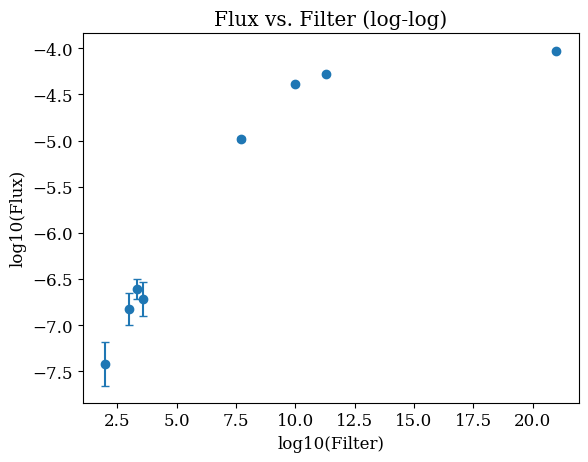

In [ ]:
fluxs = []
efluxs = []
filters = [7.7,10,11.3,21,2,3,3.35,3.6]

# Assuming the file is whitespace or tab-delimited and columns are: flux, flux_err, ..., filter (adjust indices as needed)
with open(filename, "r") as file:
    next(file)  # skip header
    for line in file:
        parts = line.strip().split()
        if len(parts) >= 4:
            fluxs.append(float(parts[0]))
            efluxs.append(float(parts[1]))
            # filters.append(parts[3])

# Convert to numpy arrays for log operations
fluxs = np.array(fluxs)
efluxs = np.array(efluxs)
filters = np.array(filters)

# Only plot points where flux and error are positive
mask = (fluxs > 0) & (efluxs > 0) & (filters > 0)
filters_mask = filters[mask]
log_fluxs = fluxs[mask]
# Error propagation in log space: err_log = err_linear / (value * ln(10))
log_efluxs = efluxs[mask] / (fluxs[mask] * np.log(10))

plt.errorbar(filters_mask, log_fluxs, yerr=log_efluxs, fmt='o', capsize=3)
plt.xlabel('log10(Filter)')
plt.ylabel('log10(Flux)')
plt.title('Flux vs. Filter (log-log)')
plt.show()

In [12]:
print(fluxs)

['1', '4', '5', '9', '3', '1', '2', '1']


In [ ]:
# # Fit the model
# results_1 = fit_dust_model(obs_wave, obs_flux, obs_flux_err, obs_limits, redshift, object_name,
#                            composition=composition, grain_size=grain_size, n_components=n_components, n_walkers=n_walkers,
#                            n_steps=n_steps, n_cores=n_cores, sigma_clip=sigma_clip, repeats=repeats,
#                            obs_wave_filters=obs_wave_filters, obs_trans_filters=obs_trans_filters,
#                            plot=True, output_dir='.')

In [ ]:

# # Fit the model
# full_model(filename, object_name, redshift, n_steps, n_walkers, composition=composition,
#            grain_size=grain_size, n_cores=n_cores, sigma_clip=sigma_clip, repeats=repeats,
#            plot=True, output_dir='.')

In [ ]:
# Fit the two component model
# results_2 = fit_dust_model(obs_wave, obs_flux, obs_flux_err, obs_limits, redshift, object_name, grain_size=grain_size,
#                            n_components=1, n_walkers=n_walkers, n_steps=n_steps, n_cores=n_cores,
#                            sigma_clip=sigma_clip, repeats=repeats, obs_wave_filters=obs_wave_filters,
#                            obs_trans_filters=obs_trans_filters, plot=True, output_dir='.',
#                            composition_hot='silicate', composition_cold='carbon')

# Run all model functions
# full_model(filename, object_name, redshift, n_steps, n_walkers, grain_size=grain_size,
#            n_cores=n_cores, sigma_clip=sigma_clip, repeats=repeats, plot=True, output_dir='.',
#            composition_hot='silicate', composition_cold='carbon', add_sigma=True)

In [ ]:
# Fit the two component model of optically thick dust
results_2 = fit_dust_model(obs_wave, obs_flux, obs_flux_err, obs_limits, redshift, object_name, grain_size=grain_size,
                           n_components=n_components, n_walkers=n_walkers, n_steps=n_steps, n_cores=n_cores,
                           sigma_clip=sigma_clip, repeats=repeats, obs_wave_filters=obs_wave_filters,
                           obs_trans_filters=obs_trans_filters, plot=True, output_dir='.',
                           dust_type='thick', radius=1e16)